# **BUSINESS PROBLEM - 2**
---

## **A. Background**: 

When an order is placed by a customer of a small manufacturing company, a price quote must be developed for that order. Because each order is unique, quotes must be established on an order-by-order basis by a pricing expert. The price quote process is labor intensive, as prices depend on many factors such as the part number, customer, geographic location, market, and order volume. The sales department manager is concerned that the pricing process is too complex, and that there might be too much variability in the quoted prices. An improvement team is tasked with studying and improving the pricing process.

After interviewing experts to develop a better understanding of the current process, the team designed a study to determine if there is variability between pricing experts. That is, **do different pricing experts provide different price quotes?** 

Two randomly selected pricing experts, Mary and Barry, were asked to independently provide prices for twelve randomly selected orders. Each expert provided one price for each of the twelve orders.

## **B. Business problem**

We would like to assess if there is any difference in the average price quotes provided by Mary and Barry.

## **C. Data available:** `Price_Quotes.csv`

The data set contains the order number, and the price quotes by Mary and Barry for each order. Each row in the data set is the same order. Thus, Mary and Barry produced quotes for the same orders.

---

In [1]:
import os
import numpy as np
import scipy as sp
import statsmodels.api as sm
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter
from IPython.display import display

In [3]:
# fetching data from source
data_source = "rishikumarrajvansh/hypothesis-testing-case-study"
data = "Price_Quotes.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  data_source,
  data,
)

In [5]:
display(df)

,Order_Number,Barry_Price,Mary_Price
0,1,126,114
1,2,110,118
2,3,138,114
3,4,142,111
4,5,146,129
5,6,136,119
6,7,94,97
7,8,103,104
8,9,140,127
9,10,152,133


## 1. Visualization

{'whiskers': [<matplotlib.lines.Line2D at 0x7f7ed62977a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f7ed6297da0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f7ed6297440>,
 'medians': [<matplotlib.lines.Line2D at 0x7f7ed62983b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f7ed6298590>,
 'means': []}

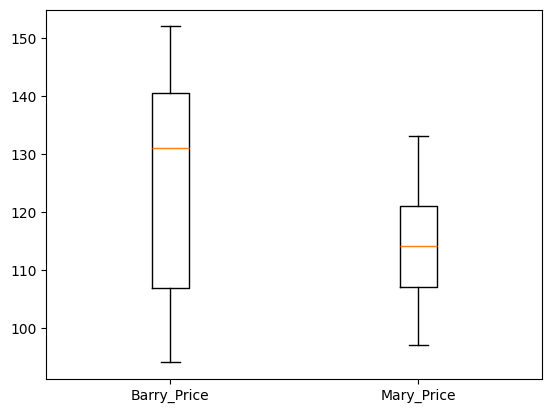

In [16]:
labels = df.columns[1:]
plt.boxplot([df["Barry_Price"], df["Mary_Price"]], 
            tick_labels=labels)

## 2. Normality test 

In [17]:
# Shapiro-Wilk test
stat_barry, p_barry = sp.stats.shapiro(df["Barry_Price"])
stat_mary, p_mary = sp.stats.shapiro(df["Mary_Price"])

print(f"Barry-price p-value: {p_barry}")
if p_barry < 0.05:
    print("Reject H0. Warning: The Barry-price distribution is not normal")
else:
    print("Fail to reject H0. Assumption met: The Barry-price distribution is normal.")

print(f"Barry-price p-value: {p_mary}")
if p_mary < 0.05:
    print("Reject H0. Warning: The Mary-price distribution is not normal")
else:
    print("Fail to reject H0. Assumption met: The Mary-price distribution is normal.")

Barry-price p-value: 0.16436048515114304
Fail to reject H0. Assumption met: The Barry-price distribution is normal.
Barry-price p-value: 0.9287641488993092
Fail to reject H0. Assumption met: The Mary-price distribution is normal.


## 3. Homogeneity of variance test

In [18]:
# Levene's Test (H0: Variances are equal, H1: Variances not equal, alpha=0.05)
stat_levene, p_levene = sp.stats.levene(df["Barry_Price"], df["Mary_Price"])

print(f"Levene’s Test p-value: {p_levene}")

if p_levene < 0.05:
    print("Reject H0. Warning: Variances are NOT equal")
else:
    print("Fail to reject H0. Assumption met: Variances are equal.")

Levene’s Test p-value: 0.018965262178688033
Reject H0. Warning: Variances are NOT equal


**Comment:** So the problem is the two-mean test problem with normal distributions and unequal variance. We hence adopt **Welch's t-test**.

**Null Hypothesis ($H_0$):** The average price quotes provided by Mary and Barry are the same.

**Alternative Hypothesis ($H_1$):** The average price quotes provided by Mary and Barry are different.

**Significant level:** $\alpha=0.05$

In [22]:
# Welch's t-test
t_stat, p_val = sp.stats.ttest_ind(df["Barry_Price"], df["Mary_Price"], equal_var=False)

print(f"Welch's t-test p-value: {p_val}")

if p_val < 0.05:
    print("Reject H0: The average price quotes provided by Mary and Barry are significantly different")
else:
    print("Fail to reject H0: The average price quotes provided by Mary and Barry are similar.")

Welch's t-test p-value: 0.17540777345374783
Fail to reject H0: The average price quotes provided by Mary and Barry are similar.
